In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pysam
from Bio.Seq import Seq
import h5py

# Getting the coordinates

In [3]:
ml_response = pd.read_csv('data/psi_response.csv')
ml_response

,gene_id,event_id,K562_summed_tpm,GM12878_summed_tpm,K562_alt_tpm,GM12878_alt_tpm,K562_gene_level_tpm,GM12878_gene_level_tpm,K562_SE_psi,GM12878_SE_psi
0,ENSG00000228794,ENSG00000228794;SE:chr1:829104-847654:847806-8...,0.846337,0.558709,0.739572,0.309630,1.053846,0.892095,0.778902,0.551136
1,ENSG00000224051,ENSG00000224051;SE:chr1:1325102-1326836:132703...,0.499687,1.133219,0.492760,1.120903,0.576341,1.146438,0.983660,0.971831
2,ENSG00000160072,ENSG00000160072;SE:chr1:1486668-1487863:148791...,1.236285,1.539202,1.172019,1.475816,1.344589,1.576687,0.861646,0.863808
3,ENSG00000160072,ENSG00000160072;SE:chr1:1489274-1489692:148981...,1.172019,1.475816,0.611723,0.610660,1.344589,1.576687,0.270325,0.133512
4,ENSG00000197530,ENSG00000197530;SE:chr1:1624901-1624991:162518...,0.220108,0.382017,0.184691,0.359835,0.833147,1.226858,0.916667,0.948052
...,...,...,...,...,...,...,...,...,...,...
7509,ENSG00000071889,ENSG00000071889;SE:chrX:154507490-154507811:15...,1.250908,1.129045,1.177536,1.055760,1.467756,1.265525,0.843679,0.843563
7510,ENSG00000071889,ENSG00000071889;SE:chrX:154511871-154512823:15...,1.091667,1.020361,1.081707,0.988113,1.467756,1.265525,0.977143,0.927746
7511,ENSG00000071889,ENSG00000071889;SE:chrX:154511871-154512314:15...,1.184691,1.080626,0.522444,0.382017,1.467756,1.265525,0.212500,0.193467
7512,ENSG00000130830,ENSG00000130830;SE:chrX:154792285-154799745:15...,2.348324,1.070407,0.453318,-1.000000,2.468805,1.156246,0.012292,0.000000


In [4]:
def get_coordinates(event):
    """
    Get the coordinates of the event, in terms of intron1, exon, and intron2.
    Respects strand information.
    """
    event = event.split(':')
    intron1 = event[2]
    intron2 = event[3]
    strand = event[4]
    exon_start = intron1.split('-')[1]
    exon_end = intron2.split('-')[0]
    exon1 = f"{exon_start}-{exon_end}"
    if strand == '+':
        return (":".join(event), intron1, exon1, intron2)
    else:
        return (":".join(event), intron2, exon1, intron1)

In [9]:
coordinates = ml_response['event_id'].apply(get_coordinates)

exon_coordinates = pd.DataFrame(coordinates.to_list(), columns=['event_id', 'upstream', 'exon', 'downstream'])
exon_coordinates['upstream_length'] = exon_coordinates['upstream'].apply(lambda x: int(x.split('-')[1]) - int(x.split('-')[0]))
exon_coordinates['exon_length'] = exon_coordinates['exon'].apply(lambda x: int(x.split('-')[1]) - int(x.split('-')[0]))
exon_coordinates['downstream_length'] = exon_coordinates['downstream'].apply(lambda x: int(x.split('-')[1]) - int(x.split('-')[0]))
exon_coordinates

,event_id,upstream,exon,downstream,upstream_length,exon_length,downstream_length
0,ENSG00000228794;SE:chr1:829104-847654:847806-8...,829104-847654,847654-847806,847806-851927,18550,152,4121
1,ENSG00000224051;SE:chr1:1325102-1326836:132703...,1325102-1326836,1326836-1327032,1327032-1327241,1734,196,209
2,ENSG00000160072;SE:chr1:1486668-1487863:148791...,1486668-1487863,1487863-1487914,1487914-1489204,1195,51,1290
3,ENSG00000160072;SE:chr1:1489274-1489692:148981...,1489274-1489692,1489692-1489811,1489811-1490257,418,119,446
4,ENSG00000197530;SE:chr1:1624901-1624991:162518...,1624901-1624991,1624991-1625185,1625185-1625286,90,194,101
...,...,...,...,...,...,...,...
7509,ENSG00000071889;SE:chrX:154507490-154507811:15...,154507861-154508289,154507811-154507861,154507490-154507811,428,50,321
7510,ENSG00000071889;SE:chrX:154511871-154512823:15...,154512936-154515760,154512823-154512936,154511871-154512823,2824,113,952
7511,ENSG00000071889;SE:chrX:154511871-154512314:15...,154512411-154512823,154512314-154512411,154511871-154512314,412,97,443
7512,ENSG00000130830;SE:chrX:154792285-154799745:15...,154799893-154805272,154799745-154799893,154792285-154799745,5379,148,7460


In [10]:
# remove rows where upstream_length or downstream_length is >10000
exon_coordinates_filtered = exon_coordinates[(exon_coordinates['upstream_length'] < 10000) & (exon_coordinates['downstream_length'] < 10000)]

# remove rows where exon_length is >1000
exon_coordinates_filtered = exon_coordinates[exon_coordinates['exon_length'] < 1000]

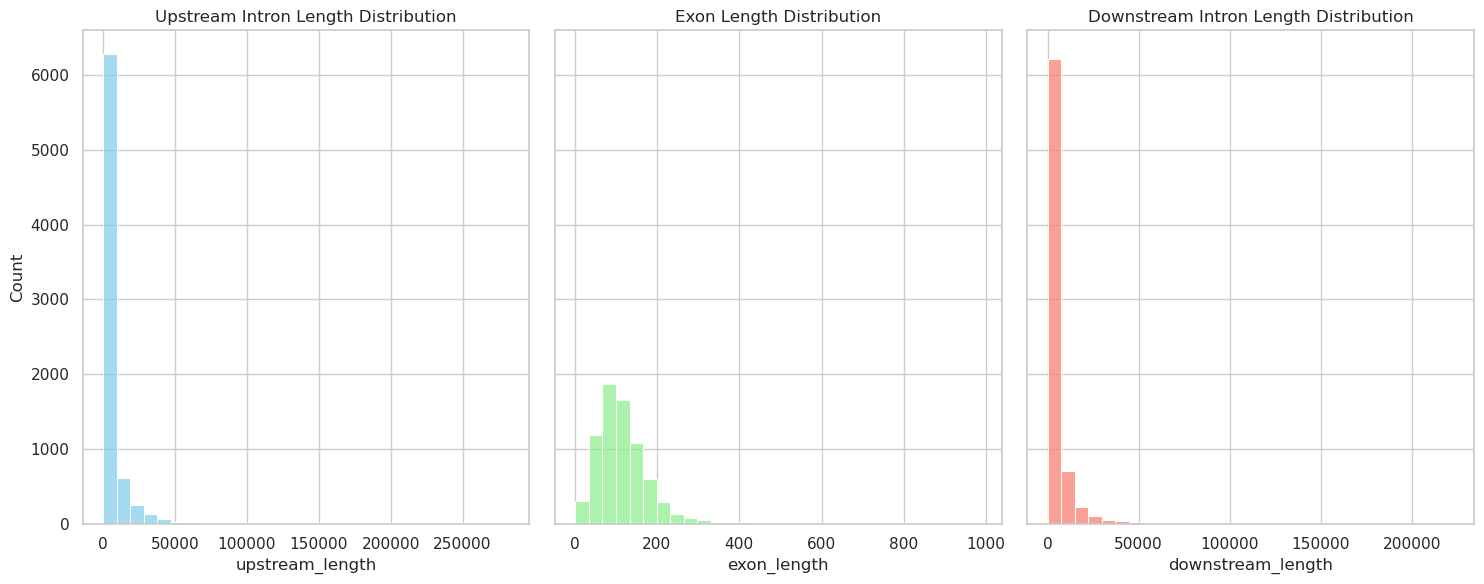

In [11]:
sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
sns.histplot(data=exon_coordinates_filtered, x='upstream_length', bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Upstream Intron Length Distribution')
sns.histplot(data=exon_coordinates_filtered, x='exon_length', bins=30, ax=axes[1], color='lightgreen')
axes[1].set_title('Exon Length Distribution')
sns.histplot(data=exon_coordinates_filtered, x='downstream_length', bins=30, ax=axes[2], color='salmon')
axes[2].set_title('Downstream Intron Length Distribution')
plt.tight_layout()
plt.show()

# Extracting the sequences

In [7]:
# read fasta file
fasta_file = pysam.FastaFile('/nfs/data/references/GCA_000001405.15_GRCh38/GCA_000001405.15_GRCh38_no_alt_analysis_set.fna')

In [24]:
event_sequences = {}

for row in exon_coordinates.iterrows():
    event_id = row[1]['event_id']
    upstream = row[1]['upstream']
    exon = row[1]['exon']
    downstream = row[1]['downstream']
    chromosome = event_id.split(':')[1]
    strand = event_id.split(':')[4]

    regions = [upstream, exon, downstream]
    region_names = ['upstream', 'exon', 'downstream']
    sequences = {}
    for region, name in zip(regions, region_names):
        start = int(region.split('-')[0])
        end = int(region.split('-')[1])
        seq = fasta_file.fetch(chromosome, start, end)

        if strand == '-':
            seq = str(Seq(seq).reverse_complement())
        sequences[f"{region}:{name}"] = seq
    event_sequences[event_id] = sequences

print(f"Sequences for {len(event_sequences)} events have been extracted.")

Sequences for 7514 events have been extracted.


In [26]:
print(list(event_sequences.keys())[33]) 
event_sequences[list(event_sequences.keys())[33]]  # Display the sequences for the first event

ENSG00000116688;SE:chr1:11980484-11981810:11981853-11981970:+


{'11980484-11981810:upstream': 'GTGAGAGGGCGAGCAAGCCGGGGTGGCGGGGACTGGCCCGGCCCGGCCCGGCGAGTCCTGAGCAGCTCGGCGTGGGCCGACGGGATTCTGGGGCCACGGGGGTCTGGGATGCAGTCAAGCGGGGTCCCCACTCTCCGGCCTCGCCGCCGGGCCCTCCCCGGCCCTGAGAGGAGGGGGCGGGCCACGGGACCTGGGACTGGTCGGTGGGGTCCCCTGTAGCTTCTCATCGCCCCCGCCTTTCCACCCTTCACGGCCATGTTCTACCCCTGCCCCTTCTCTATTTTTCATCCTGTCTTCATTTTGCCAGCATTTACTCAGCACCTGATAGGTGTCCACGTTCACCGCGGGAGCGCCCTGCCATCCCCACTTTGGGCAGTTACTGCCTTCTCGTTCAGCCCTGTTTACTTATATGACTTCTCACCGGACTGTAAGGCCCTGGAGGGCAGGACTGTTTCTTATCCATTTCTAACGTGGCGCCTGACACACACAGAGAAGGCACACAGAAAATGTTGAATAAATAGCTGTTAAGACGCACGAAGGCAGAACTGCCCGTTACCCCCTCTCGTAATCCTTCATTGCCCTCTTTAAATTCTCAATCATCTCTCTCTCTTCTACCCAGAAAAGGGCTCTGGTTATCTCTTTTCTACCCAGAAAAGGGCTCTGGTTATCCGCCTCTGGTGTCCCAAGGTTTGGGGCTTGGGGGAGGAAGGCAGCTCAATGTAGTTAAAAAAGGAAGGAGGCCGGTCGCAGTGGATCACACCTGTAATCCCAGCACTTTGGGAGGCTGAGGCGGGCGGATCACCTGAGGTCAGGAGTTGGAGACCAGCCTGGCCAACATGGTGAAACCCCGTCTGTGCTAAAACCAAAAACTAGCCGGGCTTGCTGGCACACGCCTGTAATCCCATCTACTCAGGAGGCTGAGGCAGGAGAATCGCTTGAACCCGGGAGGCGGAGGTTGAGCCGAGATC

In [ ]:
# save the sequences to a h5 file
with h5py.File('data/event_sequences.h5', 'w') as f:
    for event_id, sequences in event_sequences.items():
        group = f.create_group(event_id)
        for region, seq in sequences.items():
            group.create_dataset(region, data=np.bytes_(seq))